In [1]:
import os
import pandas as pd
from typing import Any
from pydantic import BaseModel
from unstructured.partition.pdf import partition_pdf

In [2]:
# Setup paths
# file_path = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\data\Audit Report Hulas Infra 208081_250514_120336.pdf"
file_path1 = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\data\IAC_2020-Balance-Sheet-Example.pdf"
poppler_path = r"C:\poppler-24.08.0\Library\bin"
tesseract_dir = r"C:\Users\ganes_3ck5\AppData\Local\Programs\Tesseract-OCR"
tesseract_exe = os.path.join(tesseract_dir, "tesseract.exe")


In [3]:
# Set environment variables
os.environ["PATH"] = f"{poppler_path}{os.pathsep}{tesseract_dir}{os.pathsep}{os.environ['PATH']}"
os.environ["POPPLER_PATH"] = poppler_path
os.environ["TESSDATA_PREFIX"] = os.path.join(tesseract_dir, "tessdata")
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'

In [5]:
# raw_pdf_elements = partition_pdf(
#     filename=file_path1,
#     # extract_images_in_pdf=True, # Extracts actual images from the PDF (e.g., logos, charts, scanned pages)
#     # image_output_dir_path=img_dir,
#     extract_image_block_types = ["Image", "Table"], # extracts image i.e is type = image
#     extract_image_block_to_payload=True,   # if true, will extract base64 for API usage
#     infer_table_structure=True, #  Detects and reconstructs table layouts in the PDF using a layout model (like YOLOX)
#     chunking_strategy="by_title", # Organizes and groups content into "chunks" or sections based on document titles/headings
#     max_characters=4000, # Specifies the maximum number of characters per chunk.
#     new_after_n_chars=3800, #  Tries to create a new chunk after approximately 3800 characters, even if the hard max is 4000
#     combine_text_under_n_chars=2000, # Combines chunks that are smaller than 2000 characters with adjacent ones
#     poppler_path=poppler_path, #  Path to the Poppler utilities, which are required to convert PDF pages into images.
#     languages=["eng"],  # For English text
#     strategy="hi_res",    # OCR processing strategy that uses high-resolution image conversion for better accuracy.
#     tesseract_path=tesseract_exe  # Full path to the Tesseract OCR executable
# )
# print(f"Successfully processed {len(raw_pdf_elements)} elements")

# # We get single types of elements from the partition_pdf function i.e CompositeElement
# set([str(type(el)) for el in raw_pdf_elements])

In [8]:
chunks = partition_pdf(
    filename=file_path1,
    infer_table_structure=True,            # extract tables
    strategy="hi_res",                     # mandatory to infer tables

    extract_image_block_types=["Image"],   # Add 'Table' to list to extract image of tables
    # image_output_dir_path=output_path,   # if None, images and tables will saved in base64

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,

    # extract_images_in_pdf=True,          # deprecated
)

In [9]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [14]:
# Each CompositeElement containes a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

chunks[0].metadata.orig_elements

In [15]:
# Each CompositeElement containes a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

chunks[1].metadata.orig_elements

In [18]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True

elements = chunks[0].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': '5e1ff047-d34e-4feb-95d1-f37a4614b310',
 'text': 'STATEMENTS OF FINANCIAL POSITION AS OF JUNE 30, 2015 AND 2014 In thousands) 2015 2014 Assets: Cash and cash equivalents $ 17,015 $ 16,189 Accounts and investment income receivables 8.917 9.780 Contnbutions receivable 51,275 31,574 Inventories 4.870 5,480 Prepaid expenses and other assets 7,801 7,363 Investments 947,366 998.024 Property and equipment, net 467.344 454.133 Total assets S$ 1504588) $ 1542.53 Liabilities and net assets: Accounts payable and other liabilities $ 40948 §$ 32,843 Deferred revenues and other 20,390 20,994 Refundable advances 3,750 3,598 Pension liability 25,403 8,746 Bonds and notes payable 230,140 283,000 Total liabilities 320,631 349,181 Net assets: Unrestricted 176,898 183,572 Temporarily restricted 640.541 658,672 Permanently restricted 366.518 351,118 Total net assets 1,183,957 1,193,362 Total liabilities and net assets S$ 1504588) $1542.53 See notes to financial statements.'

In [19]:
# separate tables from texts
tables = []
texts = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)

In [20]:
tables

[]

In [21]:
texts

In [22]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

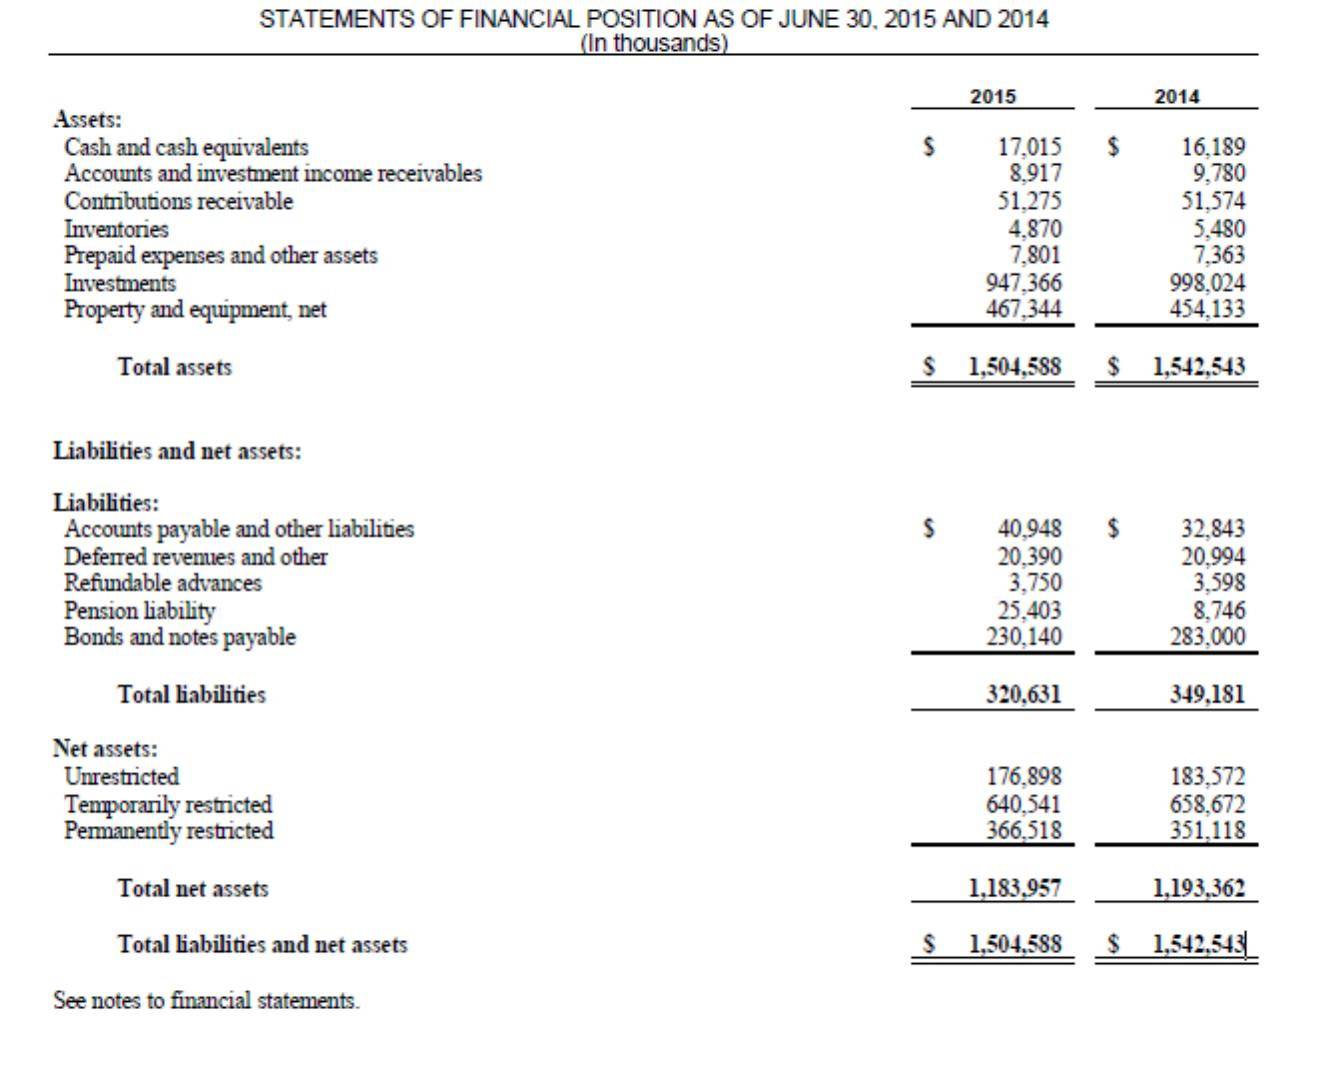

In [23]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[0])

In [24]:
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

In [26]:
# Prompt
prompt_text = prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
model = ChatOllama(model="llama3.2:latest")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [27]:
# Summarize text
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 3})

# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html, {"max_concurrency": 3})

In [29]:
text_summaries

["A balance sheet is a statement of an organization's assets, liabilities, and capital at a particular point in time, providing a comprehensive picture of its financial situation. It reports on assets and liabilities, with net assets representing the sum of annual surpluses or deficits, indicating liquidity through cash availability and asset conversion.",
 'Balance Sheet Example 2:\n\nCider Hill Players:\nDecember 31, 2009: $730,519\nDecember 31, 2008: $491,840\nNet Assets: $649,532 (2009), $673,907 (2008)\n\nAssets: \n- Total: $548,667 (2009), $491,840 (2008)\n- Current: Cash and investments ($1,184) and accounts receivable ($22,260), totaling $23,020\n- Property and Equipment: $132,067\n\nLiabilities:\n- Total: $680,416 (2009), $730,519 (2008)\n- Current: Accounts payable ($95,578) and unearned revenue ($5,012), totaling $100,590\n- Long-term: Line of credit and total liabilities ($582,827)\n\nNet Assets:\n- Unrestricted: $50,000 (2009), $49,840 (2008)\n- Temporarily restricted: $0'

In [28]:
table_summaries

[]

In [ ]:
# # Save the summarized content
# with open("IAC_2020_Balance_Sheet_text_summaries.txt", "w", encoding="utf-8") as f:
#     for summary in text_summaries:
#         f.write(summary.strip() + "\n\n")


# with open("IAC_2020_Balance_Sheet_text_summaries.txt", "r", encoding="utf-8") as f:
#     loaded_content = f.read()

# text_summaries = [s.strip() for s in loaded_content.split("\n\n") if s.strip()]
# text_summaries

In [30]:
import base64
import os
import glob
import subprocess
import uuid
import json

# === CONFIGURATION ===
MODEL_DIR = r"C:\Users\ganes_3ck5\.cache\huggingface\hub\llama_cpp"
LLAVA_EXE = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\llama.cpp\build\bin\Release\llama-mtmd-cli.exe"

IMG_SUMMARY_DIR = r"C:\Users\ganes_3ck5\DataScience\Gen_AI\Course_GenAI\Gen_AI_In-Depth\Group_Projects\Finance_App\experiments\IAC_2020_Balance_Sheet"
IMG_DIR=r"/c/Users/ganes_3ck5/DataScience/Gen_AI/Course_GenAI/Gen_AI_In-Depth/Group_Projects/Finance_App/experiments/IAC_2020_Balance_Sheet"

os.makedirs(IMG_DIR, exist_ok=True)

prompt_template = """You are an image summarizer specialized in financial documents. Analyze the image carefully and describe it in detail. The image is part of a financial report (such as a balance sheet, income statement, cash flow statement, or equity report).

If the image contains:
- Financial tables or charts: Summarize the type of data presented, major figures, trends, or categories.
- Text sections: Transcribe or summarize the content briefly.
- Logos, stamps, signatures, or seals: Identify and describe them, including their placement and potential meaning (e.g., approval, verification, branding).
- Other graphical elements: Explain their relevance in the context of the financial report.

Be clear, concise, and context-aware. Highlight anything unusual, informative, or visually important.
"""

def summarize_base64_image(base64_image: str, image_id: str):
    # Decode and save image temporarily
    image_data = base64.b64decode(base64_image)
    image_path = os.path.join(IMG_DIR, f"{image_id}.jpg")  # e.g. "image_1.jpg"
    with open(image_path, "wb") as f:
        f.write(image_data)

    # Build command for LLava CLI
    command = [
    LLAVA_EXE,
    "-m", os.path.join(MODEL_DIR, "ggml-model-q5_k.gguf"),
    "--mmproj", os.path.join(MODEL_DIR, "mmproj-model-f16.gguf"),
    "--chat-template", "vicuna",
    "--temp", "0.1",
    "-p", prompt_template,
    "--image", image_path
    ]

    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        output_text = result.stdout
    except subprocess.CalledProcessError as e:
        output_text = f"Error running LLava: {e.stderr}"

    return output_text, image_path

In [31]:
image_summaries = {}

for i, img in enumerate(images):
    image_id = f"image_{i+1}"
    print(f"Processing {image_id}...")
    summary, img_path = summarize_base64_image(img, image_id)
    image_summaries[image_id] = {
        "summary": summary,
        "image_path": img_path
    }

Processing image_1...


In [32]:
image_summaries

{'image_1': {'summary': "main: loading model: C:\\Users\\ganes_3ck5\\.cache\\huggingface\\hub\\llama_cpp\\ggml-model-q5_k.gguf\nencoding image or slice...\nimage/slice encoded in 3437 ms\ndecoding image batch 1/1, n_tokens_batch = 576\nimage decoded (batch 1/1) in 75045 ms\n\n The image displays a financial report, likely a balance sheet or income statement, for a company. The report is organized into several sections, including assets, liabilities, and equity. The assets section shows a total of $1,798,975,000, while the liabilities section shows a total of $1,798,975,000. The equity section shows a total of $1,798,975,000.\n\nThere are also several tables and charts within the report, providing additional information on the financial performance of the company. The tables and charts are spread throughout the report, with some located near the top, middle, and bottom sections. The report appears to be well-organized and informative, providing a comprehensive overview of the company's 

In [35]:
print(image_summaries['image_1'])

{'summary': "main: loading model: C:\\Users\\ganes_3ck5\\.cache\\huggingface\\hub\\llama_cpp\\ggml-model-q5_k.gguf\nencoding image or slice...\nimage/slice encoded in 3437 ms\ndecoding image batch 1/1, n_tokens_batch = 576\nimage decoded (batch 1/1) in 75045 ms\n\n The image displays a financial report, likely a balance sheet or income statement, for a company. The report is organized into several sections, including assets, liabilities, and equity. The assets section shows a total of $1,798,975,000, while the liabilities section shows a total of $1,798,975,000. The equity section shows a total of $1,798,975,000.\n\nThere are also several tables and charts within the report, providing additional information on the financial performance of the company. The tables and charts are spread throughout the report, with some located near the top, middle, and bottom sections. The report appears to be well-organized and informative, providing a comprehensive overview of the company's financial si

In [36]:
print(image_summaries['image_1']['summary'])

main: loading model: C:\Users\ganes_3ck5\.cache\huggingface\hub\llama_cpp\ggml-model-q5_k.gguf
encoding image or slice...
image/slice encoded in 3437 ms
decoding image batch 1/1, n_tokens_batch = 576
image decoded (batch 1/1) in 75045 ms

 The image displays a financial report, likely a balance sheet or income statement, for a company. The report is organized into several sections, including assets, liabilities, and equity. The assets section shows a total of $1,798,975,000, while the liabilities section shows a total of $1,798,975,000. The equity section shows a total of $1,798,975,000.

There are also several tables and charts within the report, providing additional information on the financial performance of the company. The tables and charts are spread throughout the report, with some located near the top, middle, and bottom sections. The report appears to be well-organized and informative, providing a comprehensive overview of the company's financial situation.





In [37]:
for key, value in image_summaries.items():
    print(f"Summary for {key}:")
    print(value['summary'])
    print()

Summary for image_1:
main: loading model: C:\Users\ganes_3ck5\.cache\huggingface\hub\llama_cpp\ggml-model-q5_k.gguf
encoding image or slice...
image/slice encoded in 3437 ms
decoding image batch 1/1, n_tokens_batch = 576
image decoded (batch 1/1) in 75045 ms

 The image displays a financial report, likely a balance sheet or income statement, for a company. The report is organized into several sections, including assets, liabilities, and equity. The assets section shows a total of $1,798,975,000, while the liabilities section shows a total of $1,798,975,000. The equity section shows a total of $1,798,975,000.

There are also several tables and charts within the report, providing additional information on the financial performance of the company. The tables and charts are spread throughout the report, with some located near the top, middle, and bottom sections. The report appears to be well-organized and informative, providing a comprehensive overview of the company's financial situation

In [ ]:
# with open(os.path.join(IMG_SUMMARY_DIR, "IAC_2020-Balance-Sheet_image_summaries.json"), "w", encoding="utf-8") as f:
#     json.dump(image_summaries, f, indent=2, ensure_ascii=False)

In [39]:
import uuid

from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryStore
from langchain_chroma import Chroma
from langchain_community.embeddings import GPT4AllEmbeddings
from langchain_core.documents import Document

# The vectorstore to use to index the child chunks
vectorstore = Chroma(
    collection_name="summaries",
    embedding_function=GPT4AllEmbeddings(),
    persist_directory=IMG_SUMMARY_DIR  # folder on disk
)

# The storage layer for the parent documents
store = InMemoryStore()  # <- Can we extend this to images
id_key = "doc_id"

docs_to_store = []

for image_id, summary_data in image_summaries.items():
    summary = summary_data["summary"]
    image_path = summary_data["image_path"]

    doc = Document(
        page_content=summary,
        metadata={"image_path": image_path, "image_id": image_id}
    )

    doc_id = str(uuid.uuid4())
    docs_to_store.append((doc_id, doc))

# Store all docs in memory
store.mset(docs_to_store)

# The retriever (empty to start)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

In [41]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids, texts)))

# # Add tables
# table_ids = [str(uuid.uuid4()) for _ in tables]
# summary_tables = [
#     Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
# ]
# retriever.vectorstore.add_documents(summary_tables)
# retriever.docstore.mset(list(zip(table_ids, tables)))

# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(list(zip(img_ids, images)))

In [52]:
# Retrieve
docs = retriever.invoke(
    "What is the Total Current Assets?"
)

In [53]:
for doc in docs:
    print(doc.text)
    print("-----")

BALANCE SHEET EXAMPLE 2

CIDER HILL PLAYERS STATEMENT OF FINANCIAL POSITION DECEMBER 31, 2009 AND 2008 2009 2008 $ 453,728 $ 492,511 144,616 144,113 9,121 2,400 41,759 54,167 1,874 8,743 651,098 701,934 33,794 38,363 53,000 53,000 15,082 15,082 (95,578) (100,120) 6,298 6,325 23,020 22,260 Total other assets 23,020 22,260 680,416 $ 730,519 662 5,012 5,222 31,600 25,000 20,000 30,884 56,612 30,884 56,612 548,667 491,840 50,000 50,000 50,865 132,067 Total net assets 649,532 673,907 TOTAL LIABILITIES $ 680,416 $ 730,519 NET ASSETS

ASSETS

CURRENT ASSETS

Cash

Investments

Accounts receivable

Grants receivable

Prepaid expenses

Total current assets

PROPERTY AND EQUIPMENT

Equipment

Production sets, costumes

Leasehold improvements

Less: Accumulated depreciation

Property and equipment (PE), net

OTHER ASSETS

Security deposit

TOTAL ASSETS $

LIABILITIES AND NET ASSETS

CURRENT LIABILITIES

Accounts payable

Unearned revenue

Line of credit, payable

Total current liabilities

LONG-T

In [51]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_ollama import ChatOllama
from base64 import b64decode


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {"images": b64, "texts": text}


def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element.text

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{image}"},
                }
            )

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatOllama(model="llama3.2:latest")
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOllama(model="llama3.2:latest")
        | StrOutputParser()
    )
)

In [54]:
response = chain.invoke(
    "What is the Total Current Assets?"
)

print(response)

The total current assets are not explicitly listed in the provided context. However, we can calculate them by adding up the values of the following categories:

* Cash
* Investments
* Accounts receivable
* Grants receivable
* Prepaid expenses

According to the Balance Sheet Example 2, the values for these categories are:

* Cash: $41,759
* Investments: $31,600
* Accounts receivable: $8,743
* Grants receivable: $2,400
* Prepaid expenses: Not explicitly listed in the provided context

We can only calculate the total current assets using the values that are explicitly listed. Therefore, we can estimate the total current assets as follows:

$41,759 + $31,600 + $8,743 = $82,102


In [ ]:
response = chain.invoke("What is the total amount of Non-Current Assets?")
print(response)

In [ ]:
response = chain.invoke("What is the total value of Liabilities, including Current and Non-Current Liabilities?")
print(response)

In [ ]:
response = chain.invoke("Compare Total Assets with the sum of Total Liabilities and Total Equity. Are they equal?")
print(response)

In [ ]:
response = chain.invoke("Provide a detailed breakdown of Equity accounts including Capital Stock, Treasury Stock, and Retained Earnings.")
print(response)